# Text: additional encoder experiments

Run this notebook twice by switching `MODEL_ID`/`RUN_DIR` to test the two additional text encoders.

In [2]:
from pathlib import Path
import os, json, math, random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

In [18]:
# ===== Paths =====
DATA_DIR = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# whisper transcripts
TXT_DIR = DATA_DIR / "text_whisper_large_v3"
assert TXT_DIR.exists(), f"TXT_DIR not found: {TXT_DIR}"

#RUN_TAG = "finetune_text_e5_base_v1"  # change per encoder
RUN_TAG = "all-mpnet-base-v2_v1"  # change per encoder
RUN_DIR = DATA_DIR / "runs" / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RUN_DIR / "best_by_val_pearson.pt"
HIST_PATH = RUN_DIR / "history.json"

# ===== Task =====
EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
NUM_TARGETS = len(EMOTIONS)
ID_WIDTH = 5

# ===== Model =====
MODEL_OPTIONS = [
    "intfloat/e5-base-v2",
    "sentence-transformers/all-mpnet-base-v2",
]
MODEL_ID = MODEL_OPTIONS[1]  # change to MODEL_OPTIONS[1] for second run
MAX_LEN = 128

# ===== Train =====
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

BATCH_SIZE = 32
EPOCHS = 30
LR_ENCODER = 1e-4
LR_HEAD = 1e-4
WEIGHT_DECAY = 0 #0.01
WARMUP_RATIO = 0.06
GRAD_CLIP = 1.0
USE_AMP = (DEVICE == "cuda")

LOSS_FN = nn.MSELoss()

L2_NORM_CLS = False

torch.backends.cuda.matmul.allow_tf32 = True

## Trying to improve winner's result

In [19]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("Device:", DEVICE)

Device: cuda


In [20]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})

train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

missing_cols = [c for c in (["Filename"] + EMOTIONS) if c not in train_df.columns]
assert not missing_cols, f"Missing cols in train CSV: {missing_cols}"

missing_cols = [c for c in (["Filename"] + EMOTIONS) if c not in valid_df.columns]
assert not missing_cols, f"Missing cols in valid CSV: {missing_cols}"

print("Train rows:", len(train_df), "| Val rows:", len(valid_df))
train_df.head()

Train rows: 8072 | Val rows: 4588


,Filename,Admiration,Amusement,Determination,Empathic Pain,Excitement,Joy
0,00000,0.333333,0.333333,0.0,0.0,0.333333,0.0
1,00001,0.000000,0.000000,0.0,0.0,0.500000,0.0
2,00002,0.500000,0.000000,0.0,0.0,0.000000,0.0
3,00003,0.000000,0.000000,0.5,0.0,0.000000,0.0
4,00004,0.400000,0.000000,0.0,0.0,0.200000,0.4


In [21]:
def txt_path(vid: str) -> Path:
    return TXT_DIR / f"{vid}.txt"

class TextEMIDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

        # filter out the missing texts
        keep_idx = []
        missing = []
        for i, row in self.df.iterrows():
            vid = row["Filename"]
            p = txt_path(vid)
            if p.exists():
                keep_idx.append(i)
            else:
                missing.append(vid)

        self.df = self.df.iloc[keep_idx].reset_index(drop=True)
        self.missing = missing

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vid = row["Filename"]
        text = txt_path(vid).read_text(encoding="utf-8").strip()
        # sometimes whisper can return empty
        if not text:
            text = "[NO SPEECH]"
        y = np.array([row[e] for e in EMOTIONS], dtype=np.float32)
        return {"id": vid, "text": text, "y": y}

train_ds = TextEMIDataset(train_df)
valid_ds = TextEMIDataset(valid_df)

print("Train usable:", len(train_ds), "missing txt:", len(train_ds.missing))
print("Val   usable:", len(valid_ds), "missing txt:", len(valid_ds.missing))

if len(train_ds.missing) or len(valid_ds.missing):
    pd.DataFrame({
        "split": ["train"]*len(train_ds.missing) + ["val"]*len(valid_ds.missing),
        "video_id": train_ds.missing + valid_ds.missing
    }).to_csv(RUN_DIR / "missing_txt.csv", index=False)
    print("Saved missing list:", RUN_DIR / "missing_txt.csv")

Train usable: 8072 missing txt: 0
Val   usable: 4588 missing txt: 0


In [22]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

def collate_fn(batch):
    texts = [b["text"] for b in batch]
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.float32)
    ids = [b["id"] for b in batch]

    tok = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    return {"ids": ids, "tok": tok, "y": ys}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

print("Batches | train:", len(train_loader), "val:", len(valid_loader))

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Batches | train: 253 val: 144


In [23]:
class mGTERegressor(nn.Module):
    def __init__(self, model_id: str, num_targets: int, hidden: int = 512, dropout: float = 0.2, l2_norm_cls: bool = False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_id, trust_remote_code=True)
        self.l2_norm_cls = l2_norm_cls

        # gte-multilingual-base hidden_size = 768
        d = self.encoder.config.hidden_size

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_targets)
        )

    def forward(self, tok):
        out = self.encoder(**tok)
        cls = out.last_hidden_state[:, 0, :]
        if self.l2_norm_cls:
            cls = F.normalize(cls, p=2, dim=1)
        pred = self.head(cls)
        return pred

model = mGTERegressor(MODEL_ID, NUM_TARGETS, hidden=512, dropout=0.2, l2_norm_cls=L2_NORM_CLS).to(DEVICE)
print(model)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

mGTERegressor(
  (encoder): MPNetModel(
    (embeddings): MPNetEmbeddings(
      (word_embeddings): Embedding(30527, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): MPNetEncoder(
      (layer): ModuleList(
        (0-11): 12 x MPNetLayer(
          (attention): MPNetAttention(
            (attn): MPNetSelfAttention(
              (q): Linear(in_features=768, out_features=768, bias=True)
              (k): Linear(in_features=768, out_features=768, bias=True)
              (v): Linear(in_features=768, out_features=768, bias=True)
              (o): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
    

In [24]:
@torch.no_grad()
def pearson_corr_torch(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8):
    pred = pred.float()
    target = target.float()

    vx = pred - pred.mean(dim=0, keepdim=True)
    vy = target - target.mean(dim=0, keepdim=True)

    num = (vx * vy).sum(dim=0)
    den = torch.sqrt((vx * vx).sum(dim=0) * (vy * vy).sum(dim=0)) + eps
    corr = num / den
    return float(corr.mean().item())


In [25]:
param_groups = [
    {"params": model.encoder.parameters(), "lr": LR_ENCODER},
    {"params": model.head.parameters(), "lr": LR_HEAD},
]

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_loader)
num_warmup_steps = 0 #int(WARMUP_RATIO * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print("Steps:", num_training_steps, "Warmup:", num_warmup_steps)

Steps: 7590 Warmup: 0


/tmp/ipykernel_88171/918996238.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [26]:
def move_tok_to_device(tok, device):
    return {k: v.to(device, non_blocking=True) for k, v in tok.items()}

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="train", leave=False):
        tok = move_tok_to_device(batch["tok"], DEVICE)
        y = batch["y"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred = model(tok)
            loss = LOSS_FN(pred, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * y.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    total_loss = 0.0
    all_p, all_y = [], []

    for batch in tqdm(loader, desc="eval", leave=False):
        tok = move_tok_to_device(batch["tok"], DEVICE)
        y = batch["y"].to(DEVICE, non_blocking=True)

        pred = model(tok)
        loss = LOSS_FN(pred, y)

        total_loss += loss.item() * y.size(0)
        all_p.append(pred.detach().cpu())
        all_y.append(y.detach().cpu())

    P = torch.cat(all_p, dim=0)
    Y = torch.cat(all_y, dim=0)

    mean_corr = pearson_corr_torch(P, Y)
    return {
        "loss": total_loss / len(loader.dataset),
        "mean_pearson": mean_corr,
    }

In [27]:
history = []
best_val = -1e9
best_epoch = -1
patience = 10
bad = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va = eval_model(model, valid_loader)

    row = {
        "epoch": epoch,
        "train_loss": float(tr_loss),
        "val_loss": float(va["loss"]),
        "val_mean_pearson": float(va["mean_pearson"]),
                "lr_encoder": float(optimizer.param_groups[0]["lr"]),
        "lr_head": float(optimizer.param_groups[1]["lr"]),
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} | val_loss={va['loss']:.4f} | "
        f"val_mean_pearson={va['mean_pearson']:.4f}"
    )
    
    # save history
    with open(HIST_PATH, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    # early stopping by Pearson
    if va["mean_pearson"] > best_val + 1e-4:
        best_val = va["mean_pearson"]
        best_epoch = epoch
        bad = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "best_val_mean_pearson": best_val,
                "config": {
                    "model_id": MODEL_ID,
                    "max_len": MAX_LEN,
                    "emotions": EMOTIONS,
                    "l2_norm_cls": L2_NORM_CLS,
                    "lr_encoder": LR_ENCODER,
                    "lr_head": LR_HEAD,
                    "batch_size": BATCH_SIZE,
                }
            },
            CKPT_PATH
        )
        print(f"✅ Saved best checkpoint: epoch={epoch}, val_mean_pearson={best_val:.4f}")
    else:
        bad += 1
        print(f"⏳ No improvement: {bad}/{patience}")

    if bad >= patience:
        print(f"🛑 Early stopping. Best epoch={best_epoch}, best val_mean_pearson={best_val:.4f}")
        break

print("Done. Best:", best_val, "at epoch", best_epoch)
print("Checkpoint:", CKPT_PATH)
print("History:", HIST_PATH)


train:   0%|          | 0/253 [00:00<?, ?it/s]

/tmp/ipykernel_88171/1187338959.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0363 | val_loss=0.0314 | val_mean_pearson=0.4356
✅ Saved best checkpoint: epoch=1, val_mean_pearson=0.4356


train:   0%|          | 0/253 [00:00<?, ?it/s]

...

eval:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 29 | train_loss=0.0028 | val_loss=0.0307 | val_mean_pearson=0.5141
✅ Saved best checkpoint: epoch=29, val_mean_pearson=0.5141


train:   0%|          | 0/253 [00:00<?, ?it/s]

eval:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 30 | train_loss=0.0028 | val_loss=0.0307 | val_mean_pearson=0.5140
⏳ No improvement: 1/10
Done. Best: 0.5140526294708252 at epoch 29
Checkpoint: /home/danila/networks/data/runs/all-mpnet-base-v2_v1/best_by_val_pearson.pt
History: /home/danila/networks/data/runs/all-mpnet-base-v2_v1/history.json


In [28]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.to(DEVICE)

va = eval_model(model, valid_loader)
print("Best checkpoint epoch:", ckpt["epoch"])
print("Val loss:", va["loss"])
print("Val mean Pearson:", va["mean_pearson"])

eval:   0%|          | 0/144 [00:00<?, ?it/s]

Best checkpoint epoch: 29
Val loss: 0.030715252544792612
Val mean Pearson: 0.5140526294708252


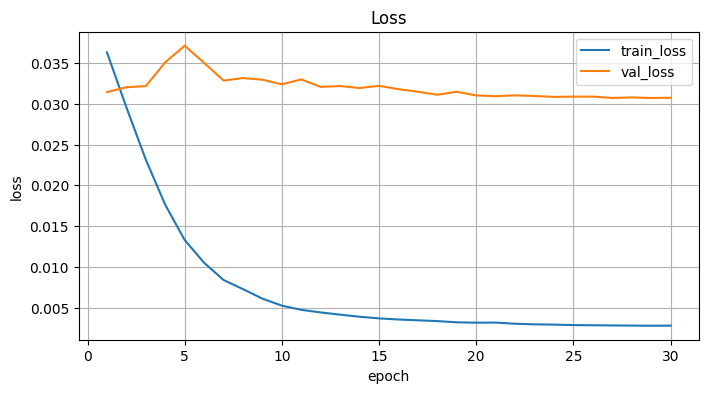

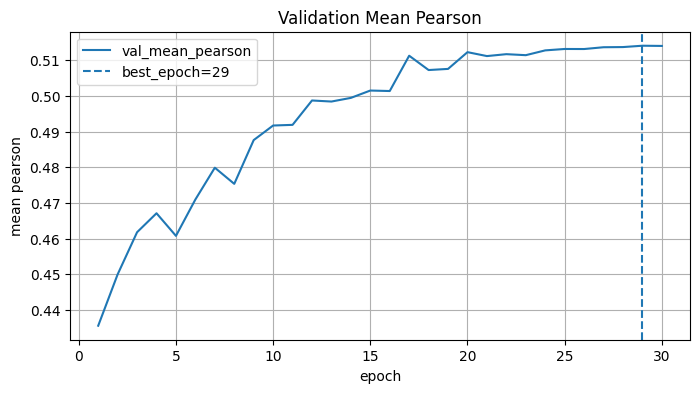

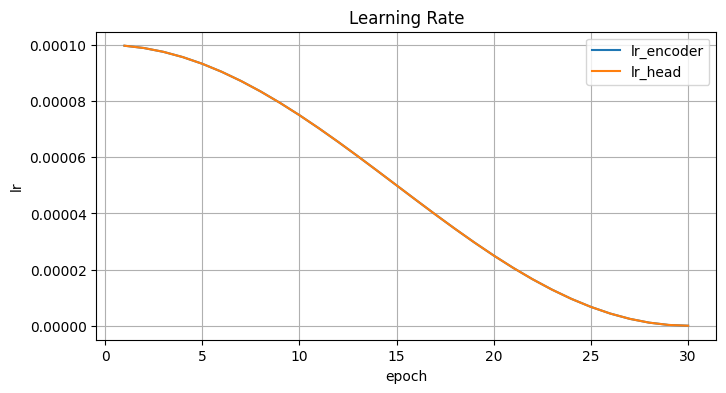

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Cell: Plot training history ---

hist_df = pd.DataFrame(history)
assert len(hist_df) > 0, "history is empty"

# 1) Loss curves
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.grid(True)
plt.legend()
plt.show()

# 2) Mean Pearson
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["val_mean_pearson"], label="val_mean_pearson")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("epoch")
plt.ylabel("mean pearson")
plt.title("Validation Mean Pearson")
plt.grid(True)
plt.legend()
plt.show()

# 3) Learning rates (robust: works if keys exist)
lr_cols = [c for c in ["lr_encoder", "lr_head", "lr"] if c in hist_df.columns]
if lr_cols:
    plt.figure(figsize=(8, 4))
    for c in lr_cols:
        plt.plot(hist_df["epoch"], hist_df[c], label=c)
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title("Learning Rate")
    plt.grid(True)
    plt.legend()
    plt.show()

In [30]:
# --- F1 (macro) on validation set ---
@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    Ps, Ys = [], []
    for batch in tqdm(loader, desc="collect", leave=False):
        tok = move_tok_to_device(batch["tok"], DEVICE)
        y = batch["y"].to(DEVICE, non_blocking=True)
        pred = model(tok)
        Ps.append(pred.detach().float().cpu())
        Ys.append(y.detach().float().cpu())
    return torch.cat(Ps, dim=0), torch.cat(Ys, dim=0)

def f1_macro_from_regression(P, Y, thr=0.5, eps=1e-8):
    pb = (P >= thr).int()
    yb = (Y >= thr).int()
    tp = (pb & yb).sum(dim=0).float()
    fp = (pb & (1 - yb)).sum(dim=0).float()
    fn = ((1 - pb) & yb).sum(dim=0).float()
    f1 = (2 * tp) / (2 * tp + fp + fn + eps)
    return float(f1.mean().item()), [float(x) for x in f1]

P, Y = collect_preds(model, valid_loader)
f1_mean, f1_per = f1_macro_from_regression(P, Y, thr=0.5)
print("Val F1 (macro, thr=0.5):", f1_mean)
for e, v in zip(EMOTIONS, f1_per):
    print(f"{e:14s}: {v:.4f}")

collect:   0%|          | 0/144 [00:00<?, ?it/s]

Val F1 (macro, thr=0.5): 0.42190590500831604
Admiration    : 0.4951
Amusement     : 0.3724
Determination : 0.4393
Empathic Pain : 0.5263
Excitement    : 0.3602
Joy           : 0.3382


In [31]:

##%%
# --- Per-emotion Pearson on validation set ---
@torch.no_grad()
def collect_preds_text(model, loader):
    model.eval()
    Ps, Ys = [], []
    for batch in tqdm(loader, desc="collect", leave=False):
        tok = move_tok_to_device(batch["tok"], DEVICE)
        y = batch["y"].to(DEVICE, non_blocking=True)
        pred = model(tok)
        Ps.append(pred.detach().float().cpu())
        Ys.append(y.detach().float().cpu())
    return torch.cat(Ps, dim=0), torch.cat(Ys, dim=0)

def pearson_per_emotion(P: torch.Tensor, Y: torch.Tensor, eps: float = 1e-8):
    P = P.float()
    Y = Y.float()
    vx = P - P.mean(dim=0, keepdim=True)
    vy = Y - Y.mean(dim=0, keepdim=True)
    num = (vx * vy).sum(dim=0)
    den = torch.sqrt((vx * vx).sum(dim=0) * (vy * vy).sum(dim=0)) + eps
    corr = num / den
    return float(corr.mean().item()), [float(c.item()) for c in corr]

P, Y = collect_preds_text(model, valid_loader)
mean_corr, per_corr = pearson_per_emotion(P, Y)
print("Val mean Pearson:", mean_corr)
for e, c in zip(EMOTIONS, per_corr):
    print(f"{e:14s}: {c:.4f}")

collect:   0%|          | 0/144 [00:00<?, ?it/s]

Val mean Pearson: 0.5140526294708252
Admiration    : 0.5795
Amusement     : 0.5452
Determination : 0.4770
Empathic Pain : 0.5472
Excitement    : 0.4740
Joy           : 0.4615


NameError: name 'torch' is not defined